In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [5]:
#  LOAD & CLEAN

df = pd.read_csv("city_day.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()

pollutant_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
                   "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"]

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Cities:", df["City"].nunique())


Shape: (29531, 19)
Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
Cities: 26


In [6]:
#   DATA QUALITY REPORT

missing = df.isna().mean().sort_values(ascending=False) * 100
print("\n--- Missing Value % by Column ---")
print(missing.round(2))

# Drop rows with no AQI at all (can't analyze target if missing)
df_clean = df.dropna(subset=["AQI"]).copy()

# Fill pollutant gaps using city-wise median (better than global median,
# since pollution baselines vary a lot by city)
for col in pollutant_cols:
    df_clean[col] = df_clean.groupby("City")[col].transform(
        lambda x: x.fillna(x.median())
    )



--- Missing Value % by Column ---
Xylene        61.32
PM10          37.72
NH3           34.97
Toluene       27.23
Benzene       19.04
AQI_Bucket    15.85
AQI           15.85
PM2.5         15.57
NOx           14.17
O3            13.62
SO2           13.05
NO2           12.14
NO            12.13
CO             6.97
City           0.00
Date           0.00
Year           0.00
Month          0.00
MonthName      0.00
dtype: float64


In [7]:
#  DESCRIPTIVE STATISTICS

print("\n--- Descriptive Statistics (pollutants + AQI) ---")
print(df_clean[pollutant_cols + ["AQI"]].describe().T.round(2))



--- Descriptive Statistics (pollutants + AQI) ---
           count    mean     std    min    25%     50%     75%      max
PM2.5    24850.0   67.10   62.29   0.04  29.48   49.24   79.58   914.94
PM10     22957.0  114.53   81.66   0.03  54.67  100.14  141.02   917.08
NO       24850.0   17.57   22.27   0.03   5.71    9.95   20.03   390.68
NO2      24850.0   28.76   24.52   0.01  11.83   21.84   37.94   362.21
NOx      24079.0   31.92   30.08   0.00  13.66   23.79   39.00   378.24
NH3      23516.0   23.47   23.35   0.01  10.35   17.06   29.71   352.89
CO       24850.0    2.32    7.02   0.00   0.58    0.92    1.47   175.81
SO2      24850.0   14.41   17.31   0.01   5.79    9.25   15.22   186.08
O3       24697.0   34.76   21.53   0.01  19.36   31.18   45.54   257.73
Benzene  22591.0    3.33   15.59   0.00   0.23    1.22    3.22   455.03
Toluene  20766.0    8.93   20.12   0.00   0.91    3.37    9.27   454.85
Xylene   12469.0    3.23    5.97   0.00   0.57    1.78    3.09   170.37
AQI      2485

## **TIME-BASED TRENDS**


--- Average AQI by Year ---
Year
2015    212.5
2016    197.2
2017    181.5
2018    182.7
2019    156.5
2020    113.5
Name: AQI, dtype: float64

--- Average AQI by Month (seasonality) ---
Month
1     231.7
2     202.9
3     164.7
4     143.4
5     135.5
6     120.2
7     111.9
8     113.6
9     115.2
10    188.6
11    241.7
12    227.1
Name: AQI, dtype: float64


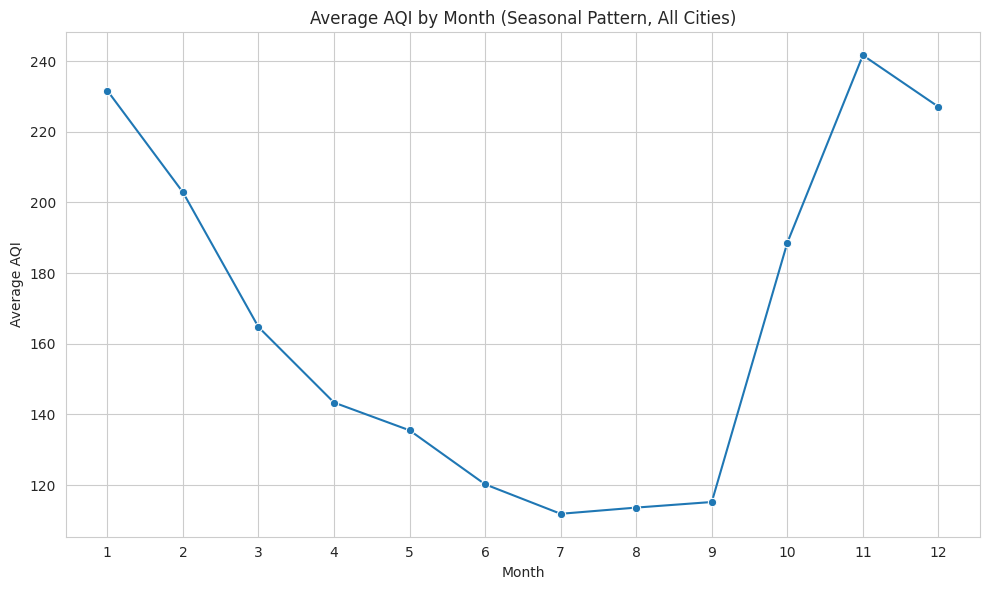

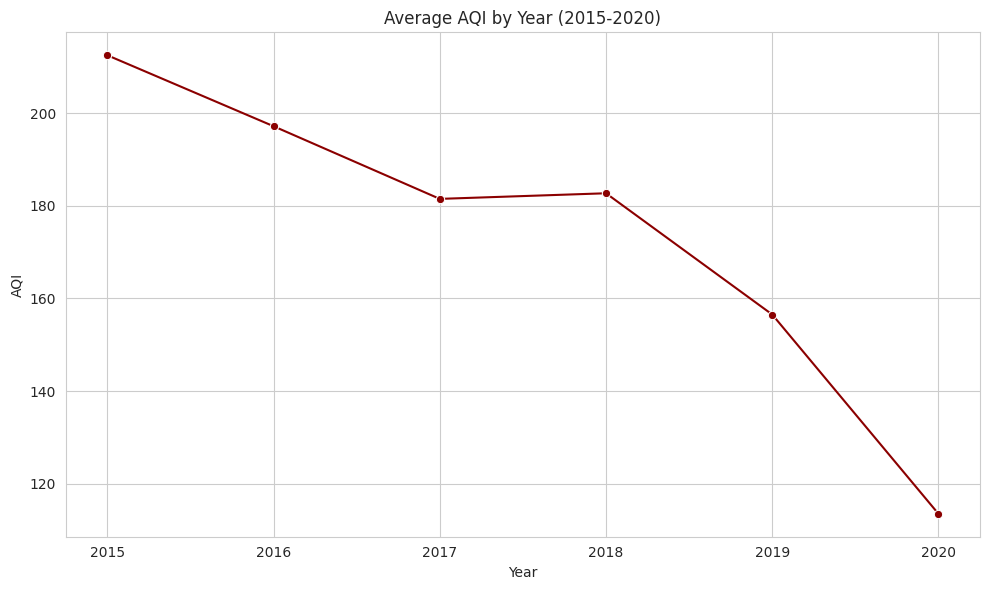

In [8]:
yearly_aqi = df_clean.groupby("Year")["AQI"].mean().round(1)
print("\n--- Average AQI by Year ---")
print(yearly_aqi)

monthly_aqi = df_clean.groupby("Month")["AQI"].mean().round(1)
print("\n--- Average AQI by Month (seasonality) ---")
print(monthly_aqi)

plt.figure()
sns.lineplot(data=df_clean, x="Month", y="AQI", estimator="mean", errorbar=None, marker="o")
plt.title("Average AQI by Month (Seasonal Pattern, All Cities)")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.savefig("monthly_aqi_trend.png", dpi=150)
plt.show()
plt.close()

plt.figure()
sns.lineplot(data=df_clean, x="Year", y="AQI", estimator="mean", errorbar=None, marker="o", color="darkred")
plt.title("Average AQI by Year (2015-2020)")
plt.tight_layout()
plt.savefig("yearly_aqi_trend.png", dpi=150)
plt.show()
plt.close()

## **CITY-WISE COMPARISON**


--- Top 10 Most Polluted Cities (avg AQI) ---
City
Ahmedabad       452.1
Delhi           259.5
Patna           240.8
Gurugram        225.1
Lucknow         218.0
Talcher         172.9
Jorapokhar      159.3
Brajrajnagar    150.3
Kolkata         140.6
Guwahati        140.1
Name: AQI, dtype: float64

--- Top 10 Least Polluted Cities (avg AQI) ---
City
Mumbai                105.4
Kochi                 104.3
Chandigarh             96.5
Amaravati              95.3
Bengaluru              94.3
Ernakulam              92.4
Thiruvananthapuram     75.9
Coimbatore             73.0
Shillong               53.8
Aizawl                 34.8
Name: AQI, dtype: float64


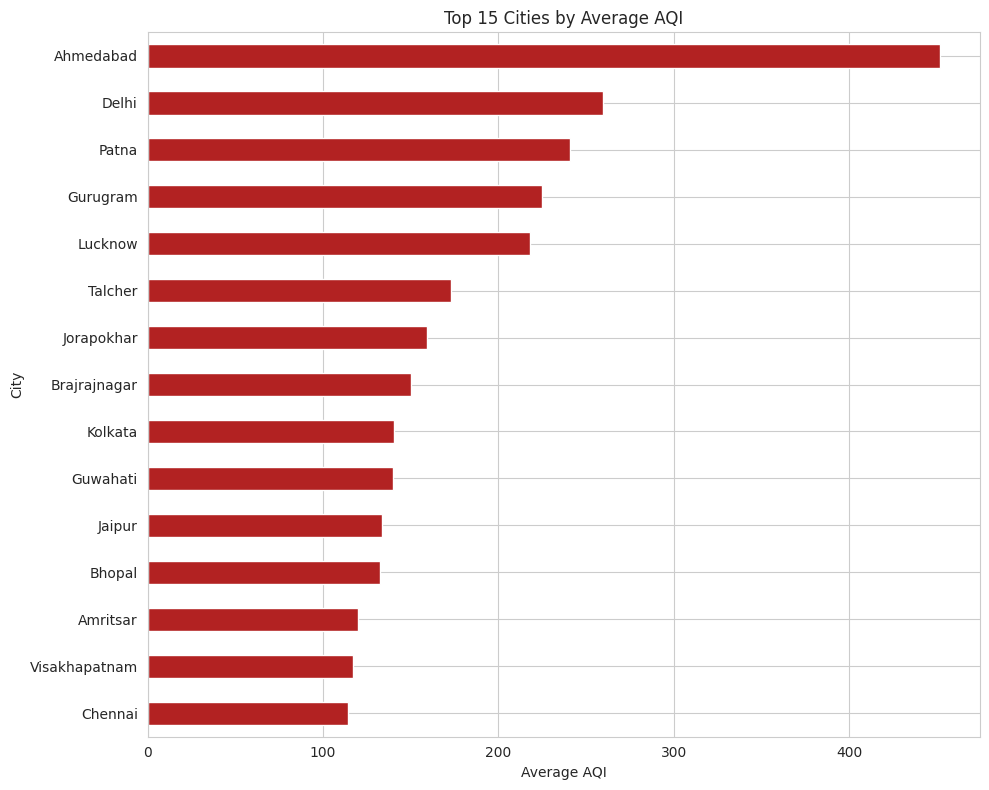

In [9]:
city_aqi = df_clean.groupby("City")["AQI"].mean().sort_values(ascending=False).round(1)
print("\n--- Top 10 Most Polluted Cities (avg AQI) ---")
print(city_aqi.head(10))
print("\n--- Top 10 Least Polluted Cities (avg AQI) ---")
print(city_aqi.tail(10))

plt.figure(figsize=(10, 8))
city_aqi.head(15).plot(kind="barh", color="firebrick")
plt.title("Top 15 Cities by Average AQI")
plt.xlabel("Average AQI")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_cities_aqi.png", dpi=150)
plt.show()
plt.close()

# **CORRELATION ANALYSIS**


--- Correlation of Pollutants with AQI ---
AQI        1.00
CO         0.68
PM2.5      0.66
NO2        0.53
PM10       0.52
SO2        0.49
NOx        0.47
NO         0.45
Toluene    0.28
O3         0.20
NH3        0.19
Xylene     0.14
Benzene    0.04
Name: AQI, dtype: float64


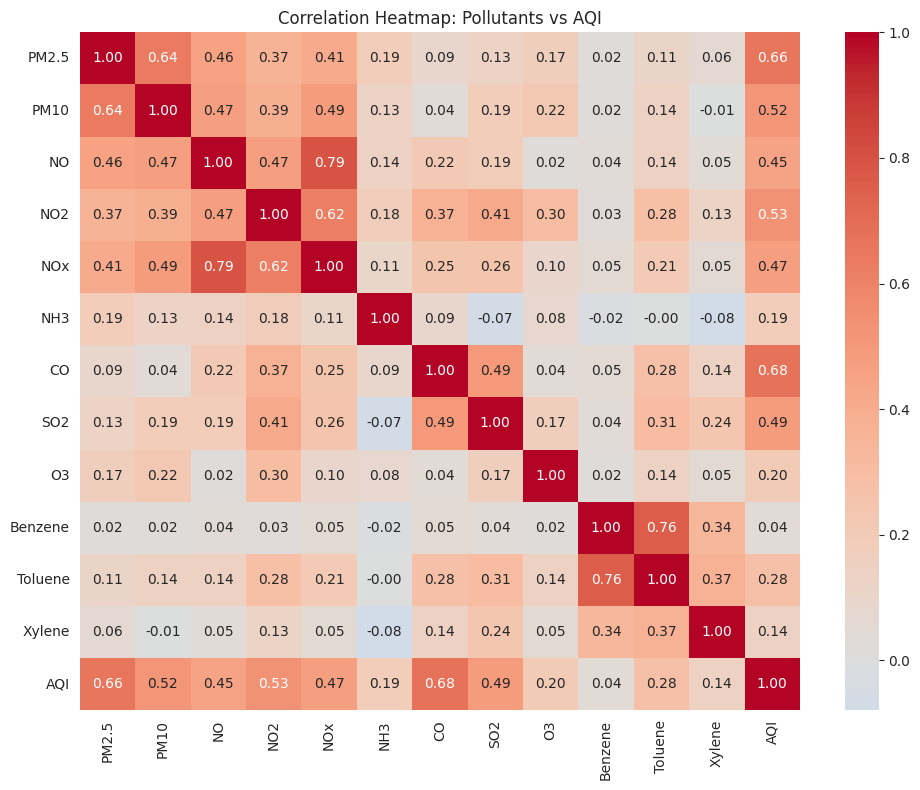

In [10]:
corr = df_clean[pollutant_cols + ["AQI"]].corr()
print("\n--- Correlation of Pollutants with AQI ---")
print(corr["AQI"].sort_values(ascending=False).round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Pollutants vs AQI")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
plt.close()

# **AQI CATEGORY DISTRIBUTION**


--- AQI Category Distribution ---
AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


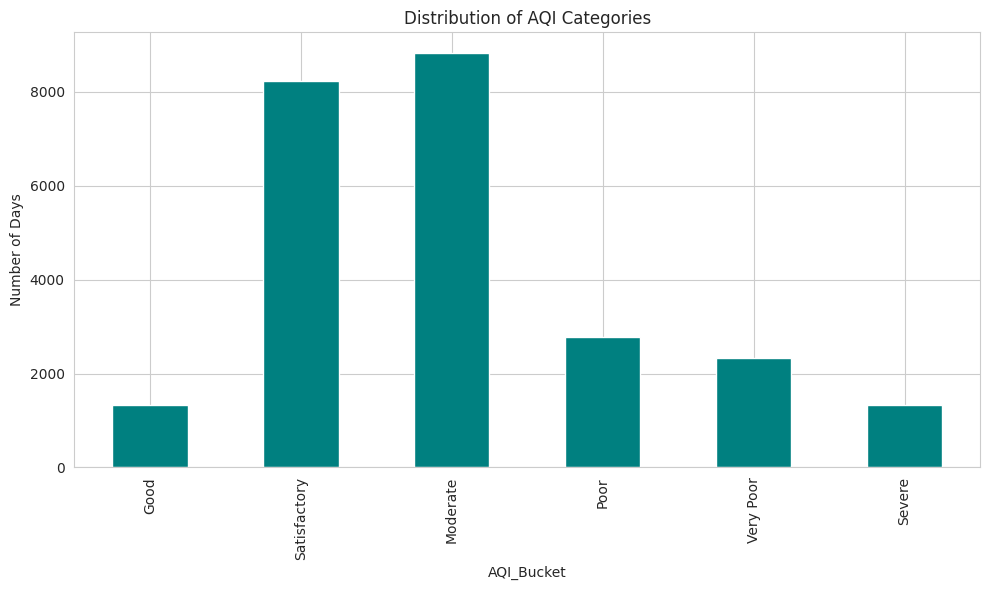

In [11]:
bucket_counts = df_clean["AQI_Bucket"].value_counts()
print("\n--- AQI Category Distribution ---")
print(bucket_counts)

plt.figure()
bucket_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
bucket_counts.reindex(bucket_order).plot(kind="bar", color="teal")
plt.title("Distribution of AQI Categories")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.savefig("aqi_category_distribution.png", dpi=150)
plt.show()
plt.close()

# **OUTLIER DETECTION (IQR method) — flag extreme pollution spikes**

In [12]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = {col: iqr_outlier_count(df_clean[col]) for col in pollutant_cols + ["AQI"]}
print("\n--- Outlier Count per Column (IQR method) ---")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")


--- Outlier Count per Column (IQR method) ---
PM2.5: 2004
PM10: 1225
NO: 2351
NO2: 1107
NOx: 1813
NH3: 1098
CO: 2303
SO2: 2435
O3: 725
Benzene: 1533
Toluene: 2417
Xylene: 1499
AQI: 1358


# **MACHINE LEARNING - AQI PREDICTION**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Prepare ML data

In [14]:
# Features
features = [
    "City",
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "Year",
    "Month"
]

# Input features
X = df_clean[features]

# Target
y = df_clean["AQI"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (24850, 15)
y shape: (24850,)


## Train/Test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 19880
Testing samples: 4970


## Preprocessing

In [16]:
numeric_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "Year",
    "Month"
]

categorical_features = ["City"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

## Train 3 models

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


## Compare models

In [18]:
results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,20.481034,40.352876,0.911072
1,Gradient Boosting,23.286572,43.365692,0.897298
2,Linear Regression,30.075741,56.946762,0.822897


## Select the best model

In [19]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("R2 Score:", round(results_df.loc[0, "R2 Score"], 4))
print("MAE:", round(results_df.loc[0, "MAE"], 2))
print("RMSE:", round(results_df.loc[0, "RMSE"], 2))

Best Model: Random Forest
R2 Score: 0.9111
MAE: 20.48
RMSE: 40.35


## Actual vs Predicted

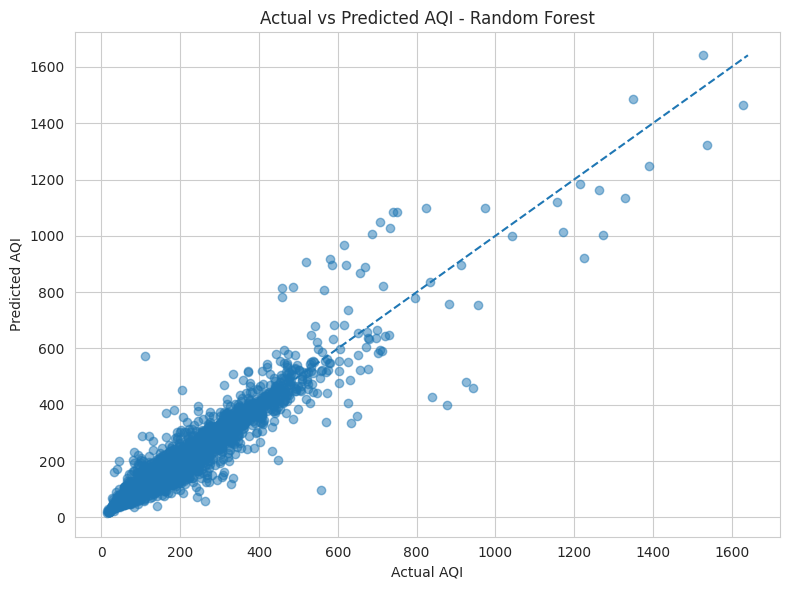

In [20]:
predictions = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, predictions, alpha=0.5)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title(f"Actual vs Predicted AQI - {best_model_name}")

min_value = min(y_test.min(), predictions.min())
max_value = max(y_test.max(), predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()